In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron as SklearnPerceptron

np.set_printoptions(precision=3, suppress=True)
plt.rcParams['figure.dpi'] = 300

In [ ]:
class Perceptron:
    """
    Manual Perceptron Learning Algorithm.
    weights[0]  -> bias (w0)
    weights[1:] -> weight for each input feature
    """
    def __init__(self, n_inputs, lr=0.1):
        self.weights = np.zeros(n_inputs + 1)
        self.lr = lr

    def net_input(self, x):
        return self.weights[0] + np.dot(self.weights[1:], x)

    def predict(self, x):
        return 1 if self.net_input(x) >= 0 else 0

    def train(self, X, y, epochs=10, gate_name=''):
        weight_history = [self.weights.copy()]

        print(f'============ Training {gate_name} gate ============')
        print(f'Initial weights: {np.round(self.weights, 3)}\n')

        for epoch in range(1, epochs + 1):
            print(f'--- Epoch {epoch} ---')
            epoch_errors = 0

            for xi, target in zip(X, y):
                pred = self.predict(xi)
                error = target - pred

                if error != 0:
                    update = self.lr * error
                    self.weights[1:] += update * xi
                    self.weights[0] += update
                    epoch_errors += 1
                    status = 'MISCLASSIFIED -> weights updated'
                else:
                    status = 'correct, no update'

                print(f'  input={xi}, target={target}, pred={pred}, '
                      f'{status}, weights now={np.round(self.weights, 3)}')

            weight_history.append(self.weights.copy())
            print(f'>> Weights after Epoch {epoch}: {np.round(self.weights, 3)} '
                  f'| errors this epoch: {epoch_errors}\n')

            if epoch_errors == 0:
                print(f'Converged after Epoch {epoch} (0 errors).\n')
                break

        return weight_history

In [ ]:
def plot_boundary_2d(X, y, weights, ax, title=''):
    """Decision boundary for a 2-input gate: w0 + w1*x1 + w2*x2 = 0"""
    w0, w1, w2 = weights
    colors = ['red' if label == 0 else 'green' for label in y]
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=130, edgecolor='k', zorder=3)
    for (x1, x2), label in zip(X, y):
        ax.annotate(str(label), (x1, x2), textcoords='offset points', xytext=(8, 8))

    x_vals = np.linspace(-0.5, 1.5, 100)
    if w2 != 0:
        y_vals = -(w0 + w1 * x_vals) / w2
        ax.plot(x_vals, y_vals, 'b-', linewidth=2)
    elif w1 != 0:
        ax.axvline(-w0 / w1, color='b', linewidth=2)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title(title, fontsize=9)
    ax.grid(alpha=0.3)


def plot_boundary_1d(X, y, weights, ax, title=''):
    """Decision boundary for the 1-input NOT gate: w0 + w1*x1 = 0"""
    w0, w1 = weights
    colors = ['red' if label == 0 else 'green' for label in y]
    ax.scatter(X[:, 0], np.zeros_like(X[:, 0], dtype=float), c=colors, s=150, edgecolor='k', zorder=3)
    for x1, label in zip(X[:, 0], y):
        ax.annotate(str(label), (x1, 0), textcoords='offset points', xytext=(0, 12))
    if w1 != 0:
        ax.axvline(-w0 / w1, color='b', linewidth=2)
    ax.set_xlim(-1, 2)
    ax.set_ylim(-1, 1)
    ax.set_yticks([])
    ax.set_xlabel('x1')
    ax.set_title(title, fontsize=9)
    ax.grid(alpha=0.3)


def plot_per_epoch(X, y, weight_history, gate_name, dim=2):
    """One subplot per epoch (weight_history[0] is the pre-training state)."""
    plot_fn = plot_boundary_2d if dim == 2 else plot_boundary_1d
    n = len(weight_history)
    cols = min(4, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.6 * rows))
    axes = np.array(axes).reshape(-1)

    for i, w in enumerate(weight_history):
        title = 'Before training (Epoch 0)' if i == 0 else f'After Epoch {i}\nw={np.round(w, 2)}'
        plot_fn(X, y, w, axes[i], title)

    for j in range(len(weight_history), len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'{gate_name} Gate — Decision Boundary After Each Epoch', fontsize=13)
    plt.tight_layout()
    plt.show()

In [ ]:
X2 = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or  = np.array([0, 1, 1, 1])
y_and = np.array([0, 0, 0, 1])

X1 = np.array([[0], [1]])
y_not = np.array([1, 0])

============ Training OR gate ============
Initial weights: [0. 0. 0.]

--- Epoch 1 ---
  input=[0 0], target=0, pred=1, MISCLASSIFIED -> weights updated, weights now=[-0.1  0.   0. ]
  input=[0 1], target=1, pred=0, MISCLASSIFIED -> weights updated, weights now=[0.  0.  0.1]
  input=[1 0], target=1, pred=1, correct, no update, weights now=[0.  0.  0.1]
  input=[1 1], target=1, pred=1, correct, no update, weights now=[0.  0.  0.1]
>> Weights after Epoch 1: [0.  0.  0.1] | errors this epoch: 2

--- Epoch 2 ---
  input=[0 0], target=0, pred=1, MISCLASSIFIED -> weights updated, weights now=[-0.1  0.   0.1]
  input=[0 1], target=1, pred=1, correct, no update, weights now=[-0.1  0.   0.1]
  input=[1 0], target=1, pred=0, MISCLASSIFIED -> weights updated, weights now=[0.  0.1 0.1]
  input=[1 1], target=1, pred=1, correct, no update, weights now=[0.  0.1 0.1]
>> Weights after Epoch 2: [0.  0.1 0.1] | errors this epoch: 2

--- Epoch 3 ---
  input=[0 0], target=0, pred=1, MISCLASSIFIED -> weigh

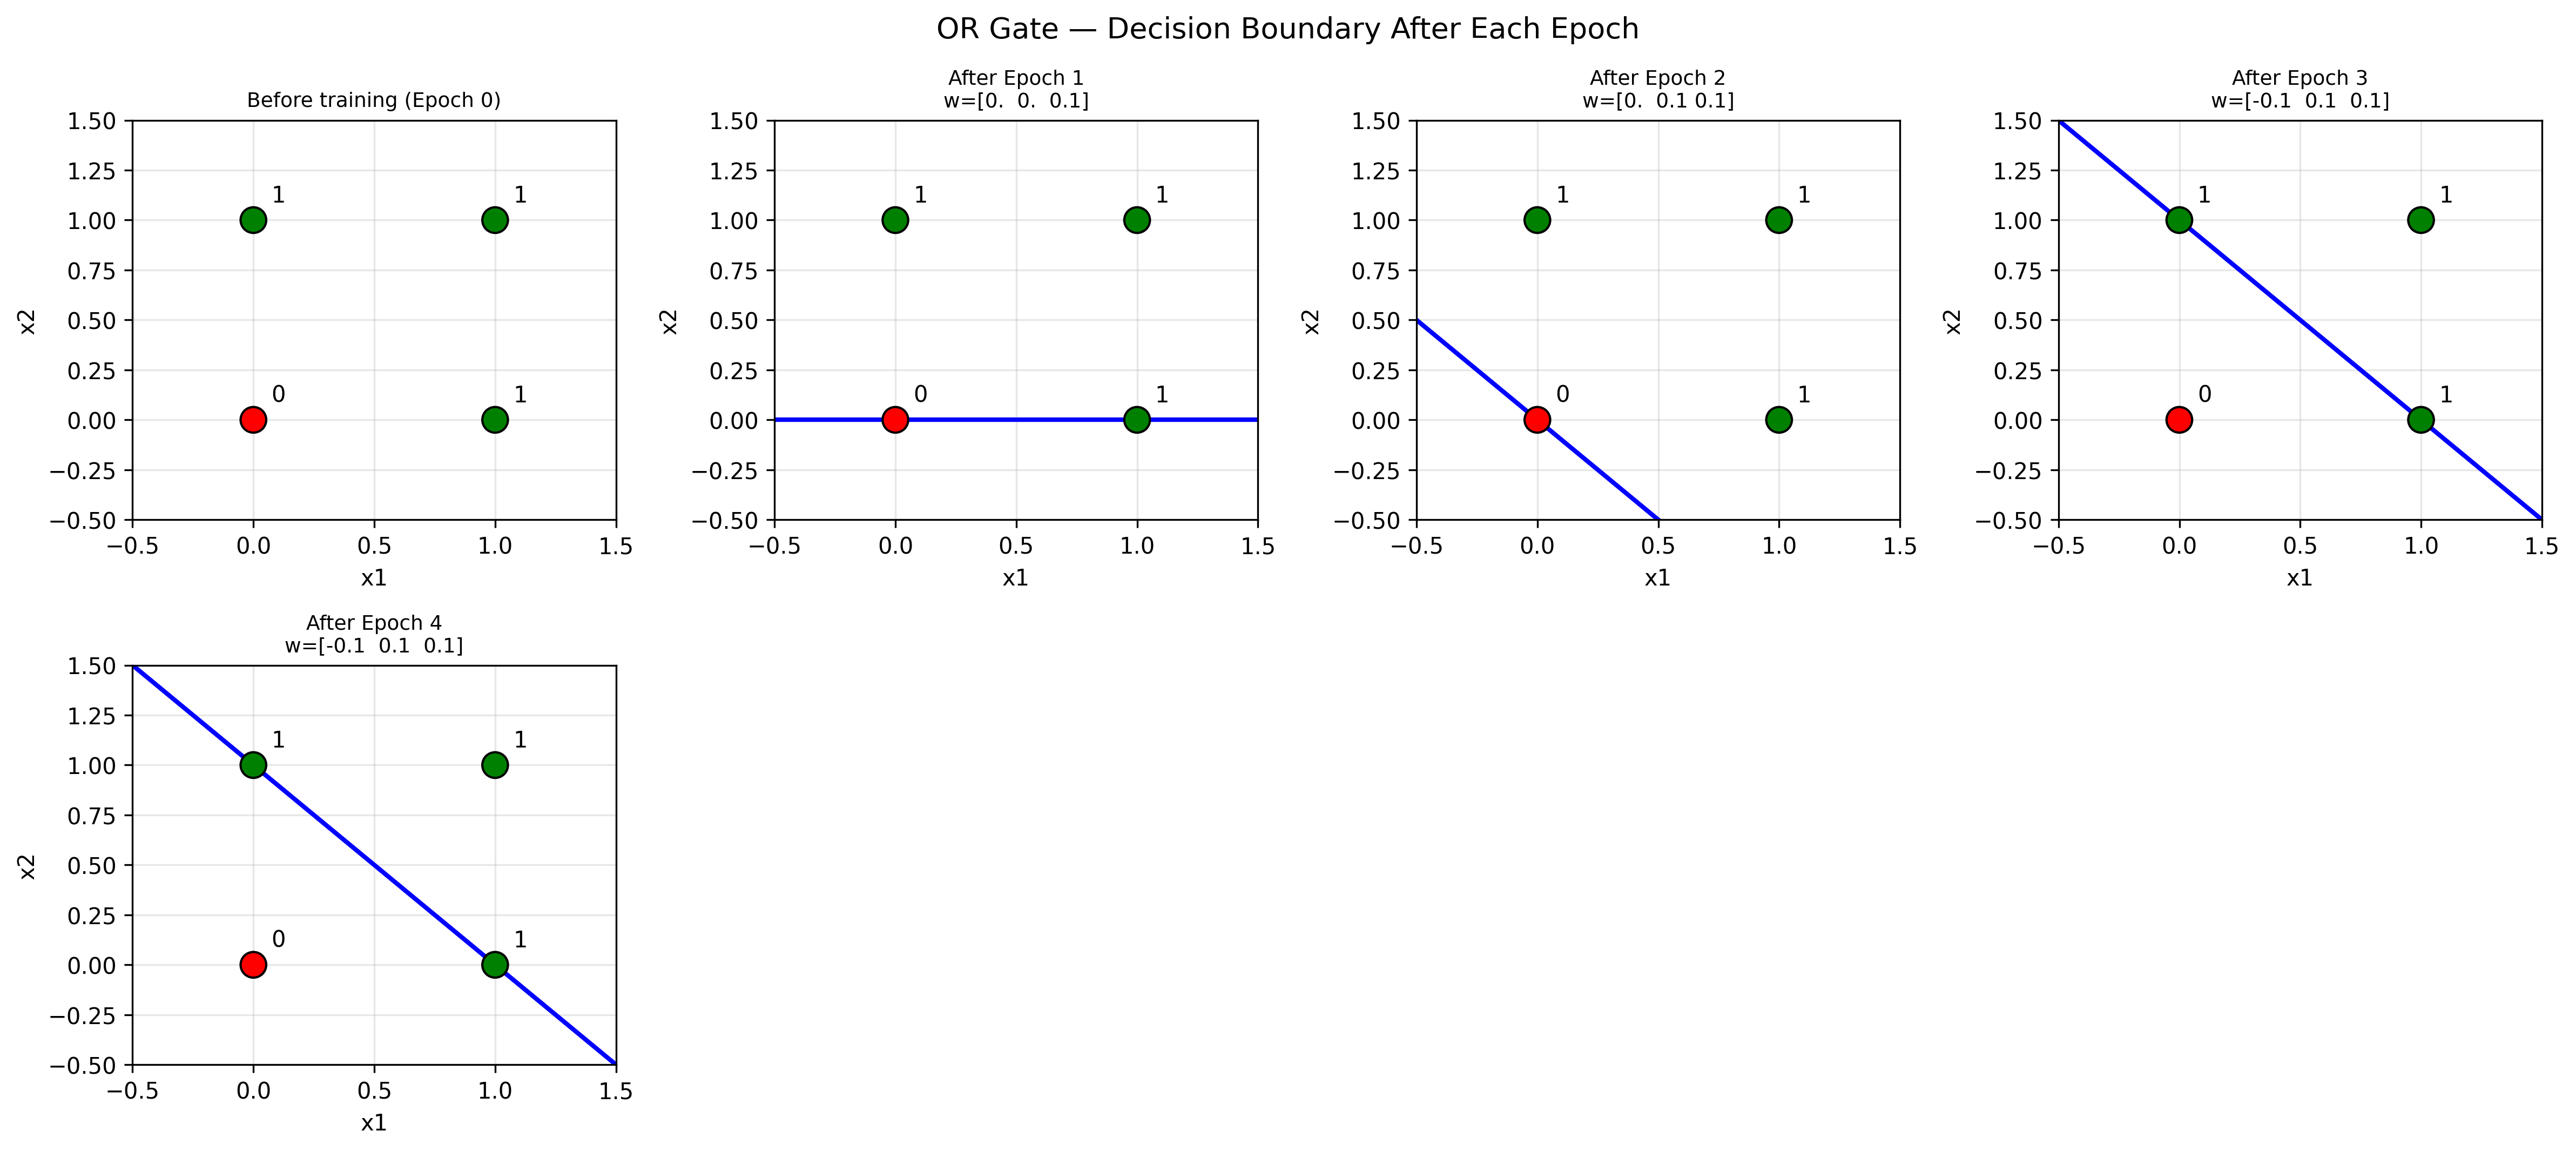

In [ ]:
p_or = Perceptron(n_inputs=2, lr=0.1)
history_or = p_or.train(X2, y_or, epochs=10, gate_name='OR')
plot_per_epoch(X2, y_or, history_or, gate_name='OR', dim=2)

============ Training AND gate ============
Initial weights: [0. 0. 0.]

--- Epoch 1 ---
  input=[0 0], target=0, pred=1, MISCLASSIFIED -> weights updated, weights now=[-0.1  0.   0. ]
  input=[0 1], target=0, pred=0, correct, no update, weights now=[-0.1  0.   0. ]
  input=[1 0], target=0, pred=0, correct, no update, weights now=[-0.1  0.   0. ]
  input=[1 1], target=1, pred=0, MISCLASSIFIED -> weights updated, weights now=[0.  0.1 0.1]
>> Weights after Epoch 1: [0.  0.1 0.1] | errors this epoch: 2

--- Epoch 2 ---
  input=[0 0], target=0, pred=1, MISCLASSIFIED -> weights updated, weights now=[-0.1  0.1  0.1]
  input=[0 1], target=0, pred=1, MISCLASSIFIED -> weights updated, weights now=[-0.2  0.1  0. ]
  input=[1 0], target=0, pred=0, correct, no update, weights now=[-0.2  0.1  0. ]
  input=[1 1], target=1, pred=0, MISCLASSIFIED -> weights updated, weights now=[-0.1  0.2  0.1]
>> Weights after Epoch 2: [-0.1  0.2  0.1] | errors this epoch: 3

--- Epoch 3 ---
  input=[0 0], target=0, 

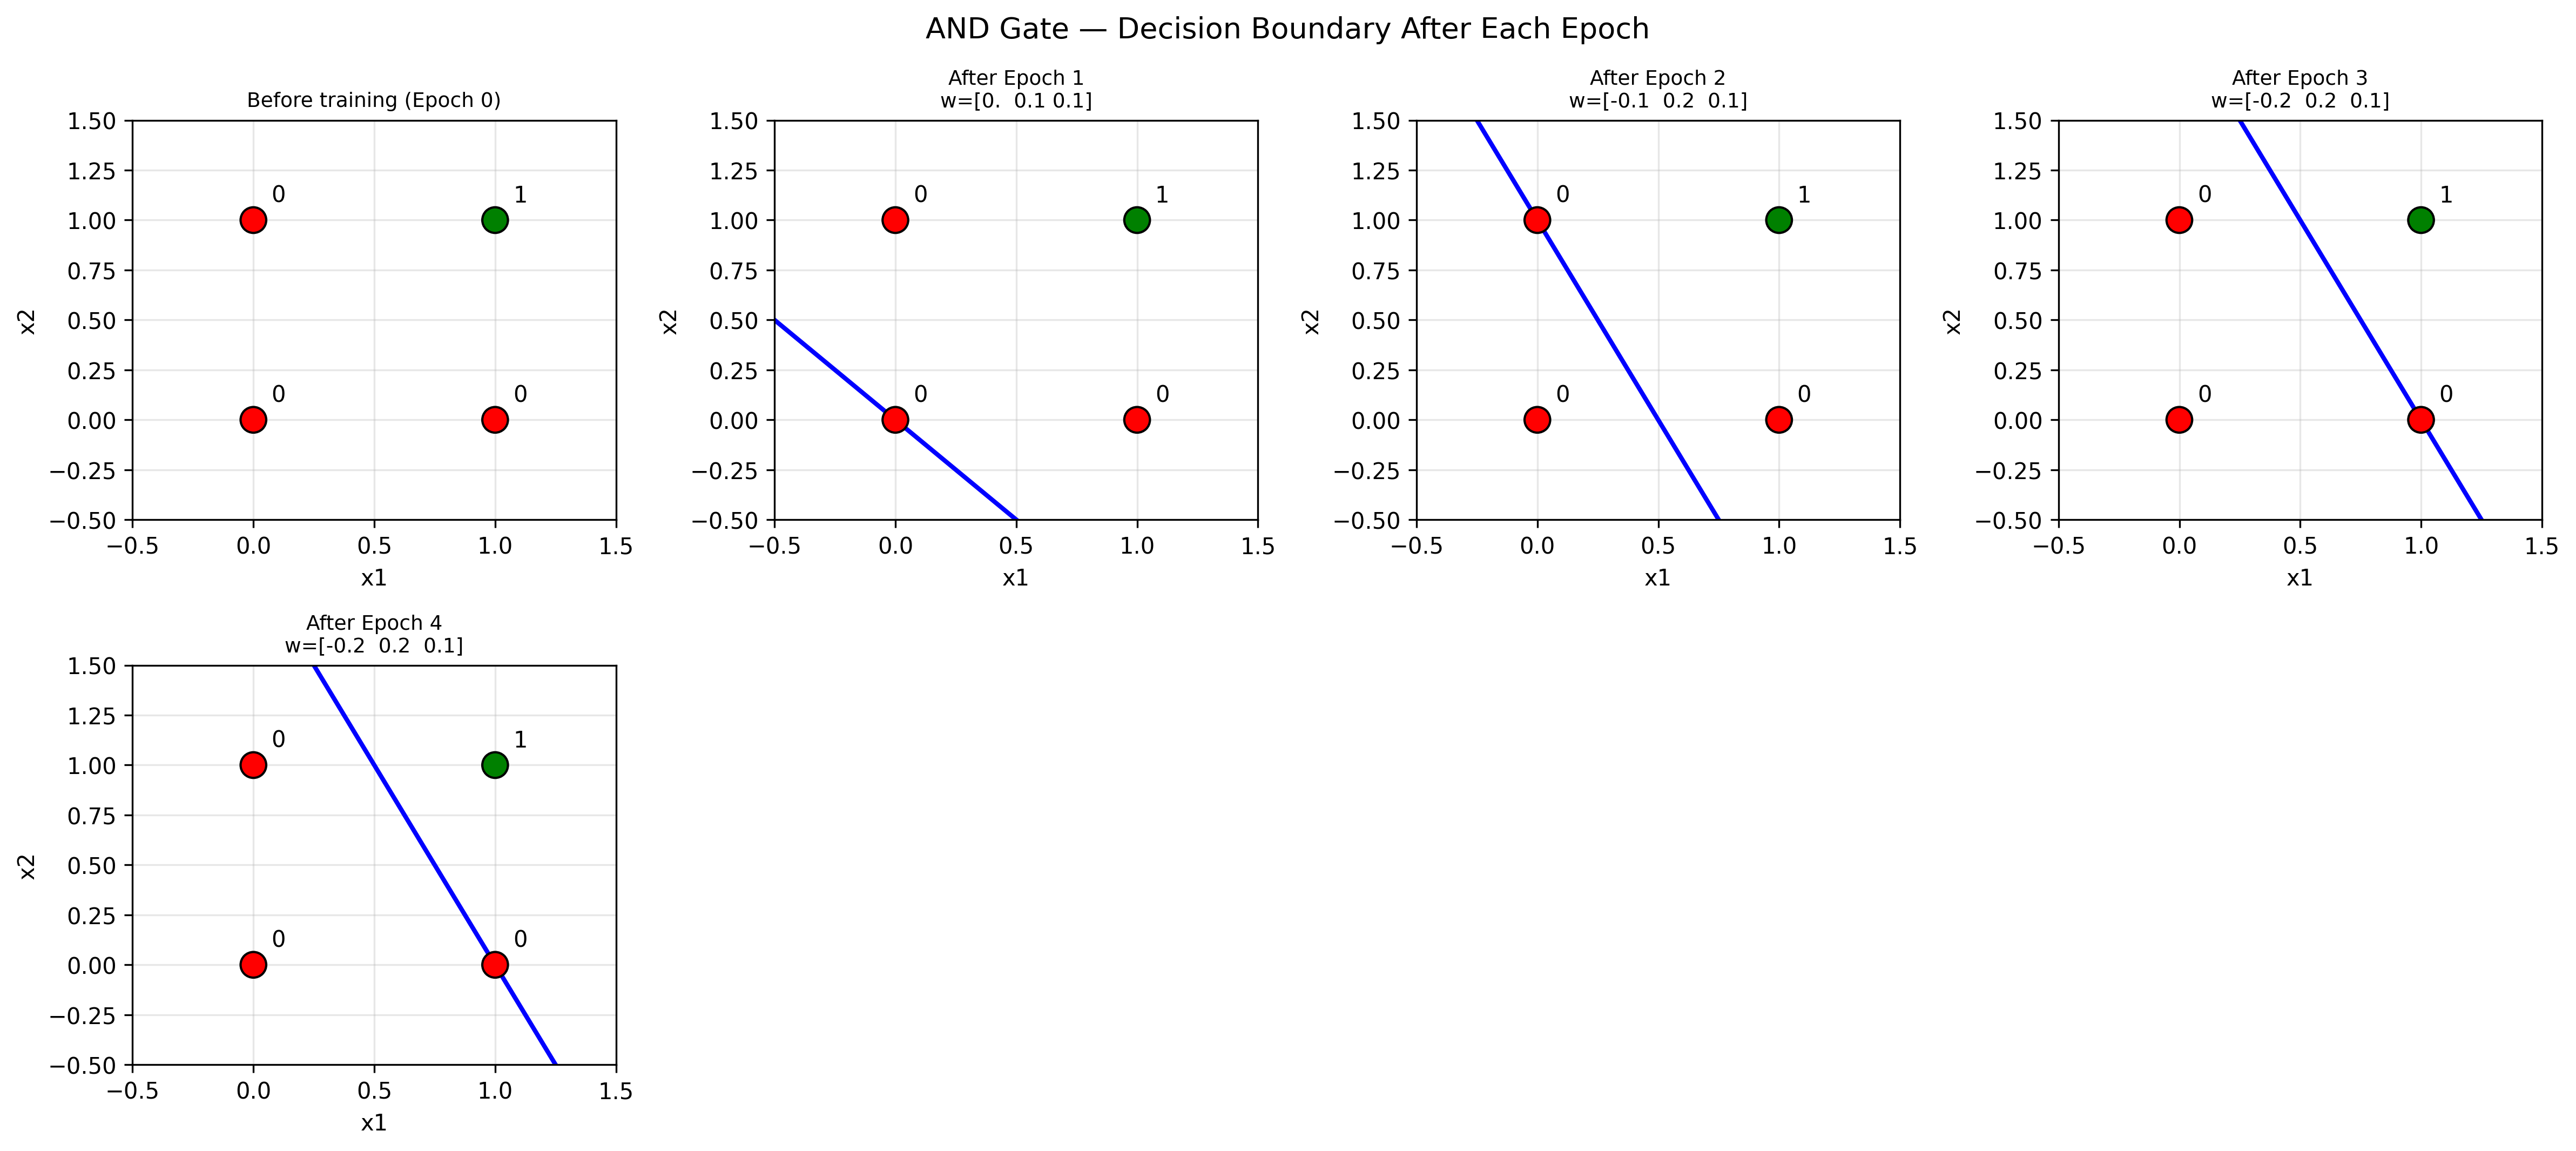

In [ ]:
p_and = Perceptron(n_inputs=2, lr=0.1)
history_and = p_and.train(X2, y_and, epochs=10, gate_name='AND')
plot_per_epoch(X2, y_and, history_and, gate_name='AND', dim=2)

============ Training NOT gate ============
Initial weights: [0. 0.]

--- Epoch 1 ---
  input=[0], target=1, pred=1, correct, no update, weights now=[0. 0.]
  input=[1], target=0, pred=1, MISCLASSIFIED -> weights updated, weights now=[-0.1 -0.1]
>> Weights after Epoch 1: [-0.1 -0.1] | errors this epoch: 1

--- Epoch 2 ---
  input=[0], target=1, pred=0, MISCLASSIFIED -> weights updated, weights now=[ 0.  -0.1]
  input=[1], target=0, pred=0, correct, no update, weights now=[ 0.  -0.1]
>> Weights after Epoch 2: [ 0.  -0.1] | errors this epoch: 1

--- Epoch 3 ---
  input=[0], target=1, pred=1, correct, no update, weights now=[ 0.  -0.1]
  input=[1], target=0, pred=0, correct, no update, weights now=[ 0.  -0.1]
>> Weights after Epoch 3: [ 0.  -0.1] | errors this epoch: 0

Converged after Epoch 3 (0 errors).



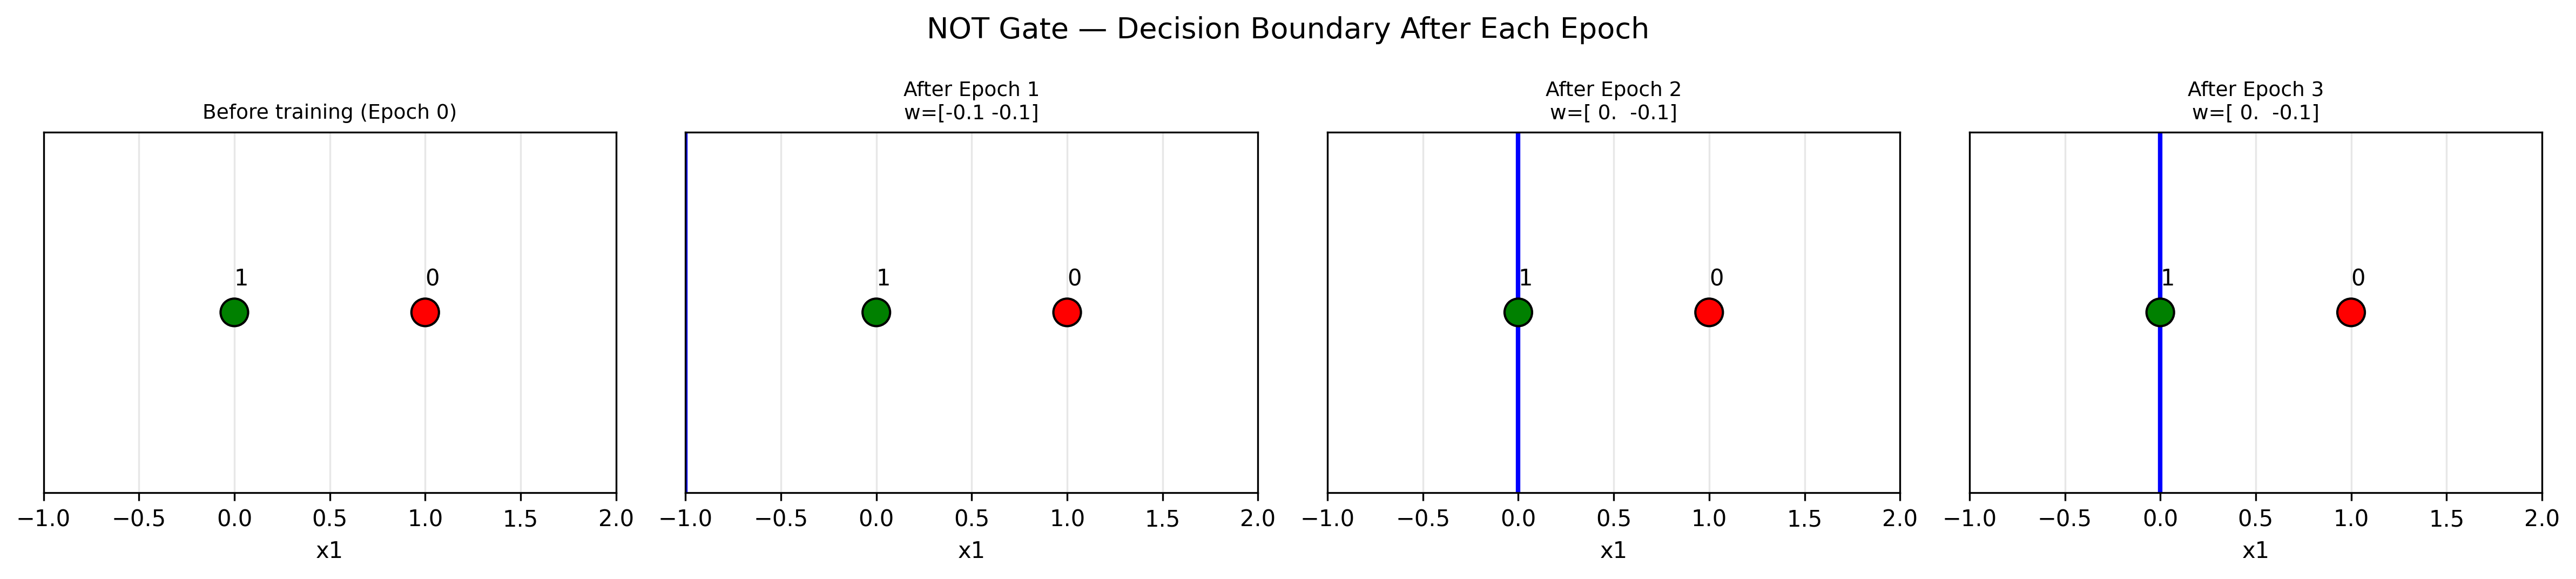

In [ ]:
p_not = Perceptron(n_inputs=1, lr=0.1)
history_not = p_not.train(X1, y_not, epochs=10, gate_name='NOT')
plot_per_epoch(X1, y_not, history_not, gate_name='NOT', dim=1)

In [ ]:
print('OR  gate final weights (bias, w1, w2):', p_or.weights)
print('AND gate final weights (bias, w1, w2):', p_and.weights)
print('NOT gate final weights (bias, w1)    :', p_not.weights)

OR  gate final weights (bias, w1, w2): [-0.1  0.1  0.1]
AND gate final weights (bias, w1, w2): [-0.2  0.2  0.1]
NOT gate final weights (bias, w1)    : [ 0.  -0.1]


In [ ]:
def train_sklearn_with_history(X, y, lr=0.1, epochs=10):
    clf = SklearnPerceptron(max_iter=1, eta0=lr,
                             tol=None, shuffle=False, warm_start=True, random_state=0)
    classes = np.unique(y)
    history = []

    clf.partial_fit(X, y, classes=classes)   # sets up coef_/intercept_
    w = np.concatenate([clf.intercept_, clf.coef_.ravel()])
    history.append(w.copy())

    for epoch in range(epochs):
        clf.partial_fit(X, y)
        w = np.concatenate([clf.intercept_, clf.coef_.ravel()])
        if not np.allclose(w, history[-1]):
            history.append(w.copy())
            print(f'Epoch {epoch+1:2d} -> weights updated to {np.round(w, 3)}')
    print('\nFinal weights (bias, w1, ...):', history[-1])
    return clf, history

Epoch  1 -> weights updated to [0.  0.1 0.1]
Epoch  2 -> weights updated to [0.  0.1 0.2]
Epoch  3 -> weights updated to [0.  0.2 0.2]
Epoch  4 -> weights updated to [-0.1  0.2  0.2]

Final weights (bias, w1, ...): [-0.1  0.2  0.2]


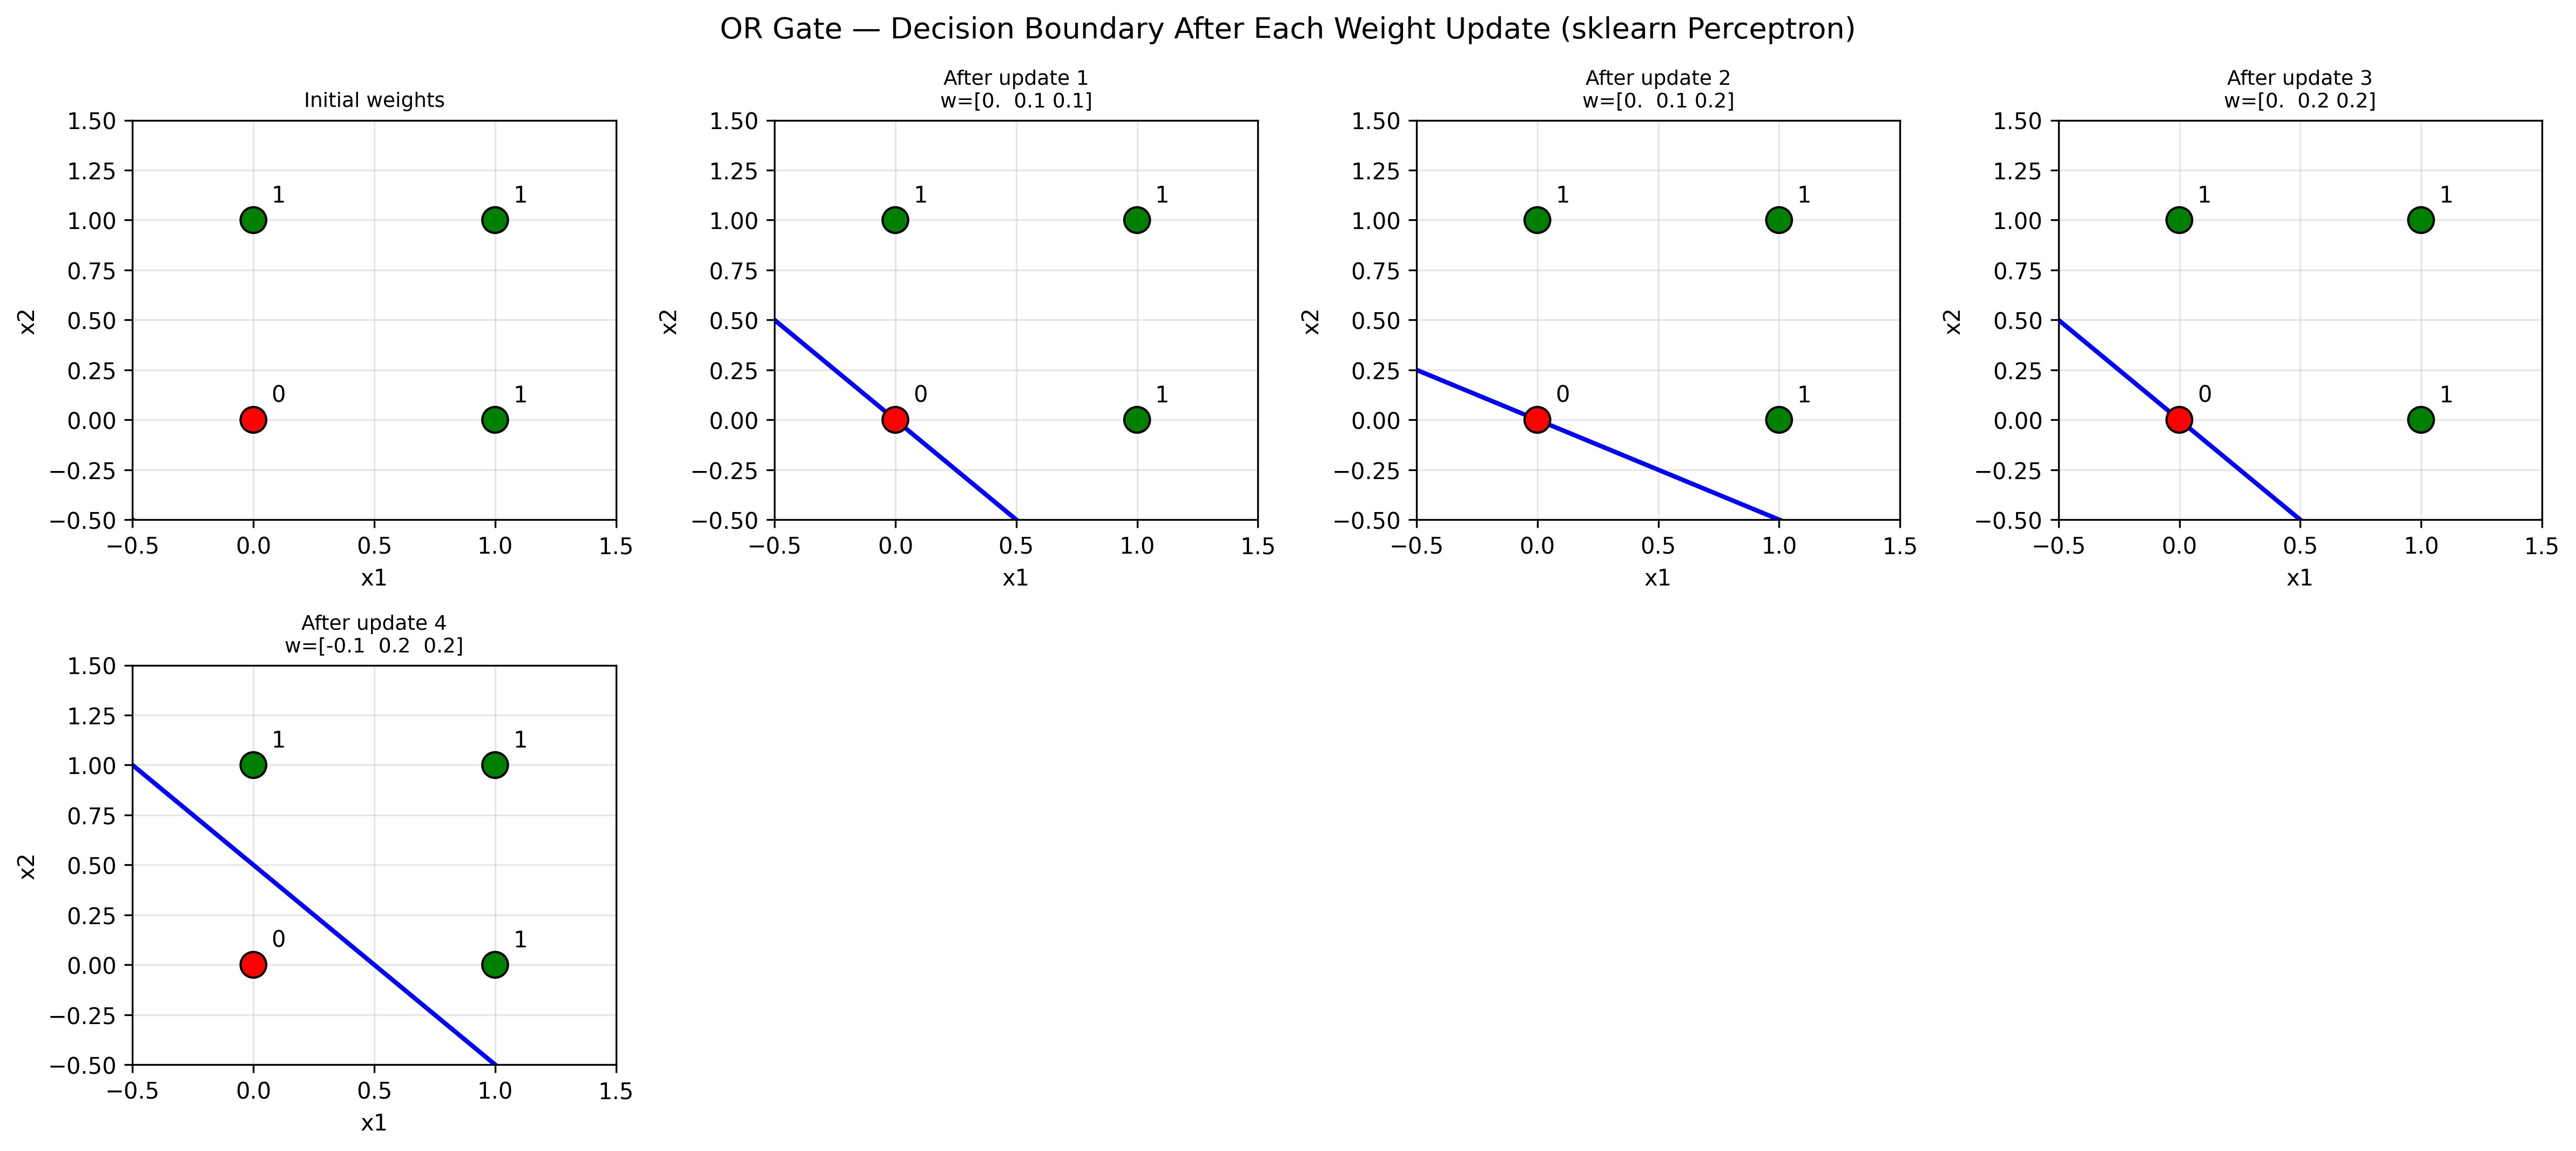

In [ ]:
sk_or, hist_or_sklearn = train_sklearn_with_history(X2, y_or)
plot_all_updates(X2, y_or, hist_or_sklearn, 'OR', 'sklearn Perceptron', dim=2)

Epoch  1 -> weights updated to [-0.1  0.2  0.1]
Epoch  2 -> weights updated to [-0.2  0.2  0.1]

Final weights (bias, w1, ...): [-0.2  0.2  0.1]


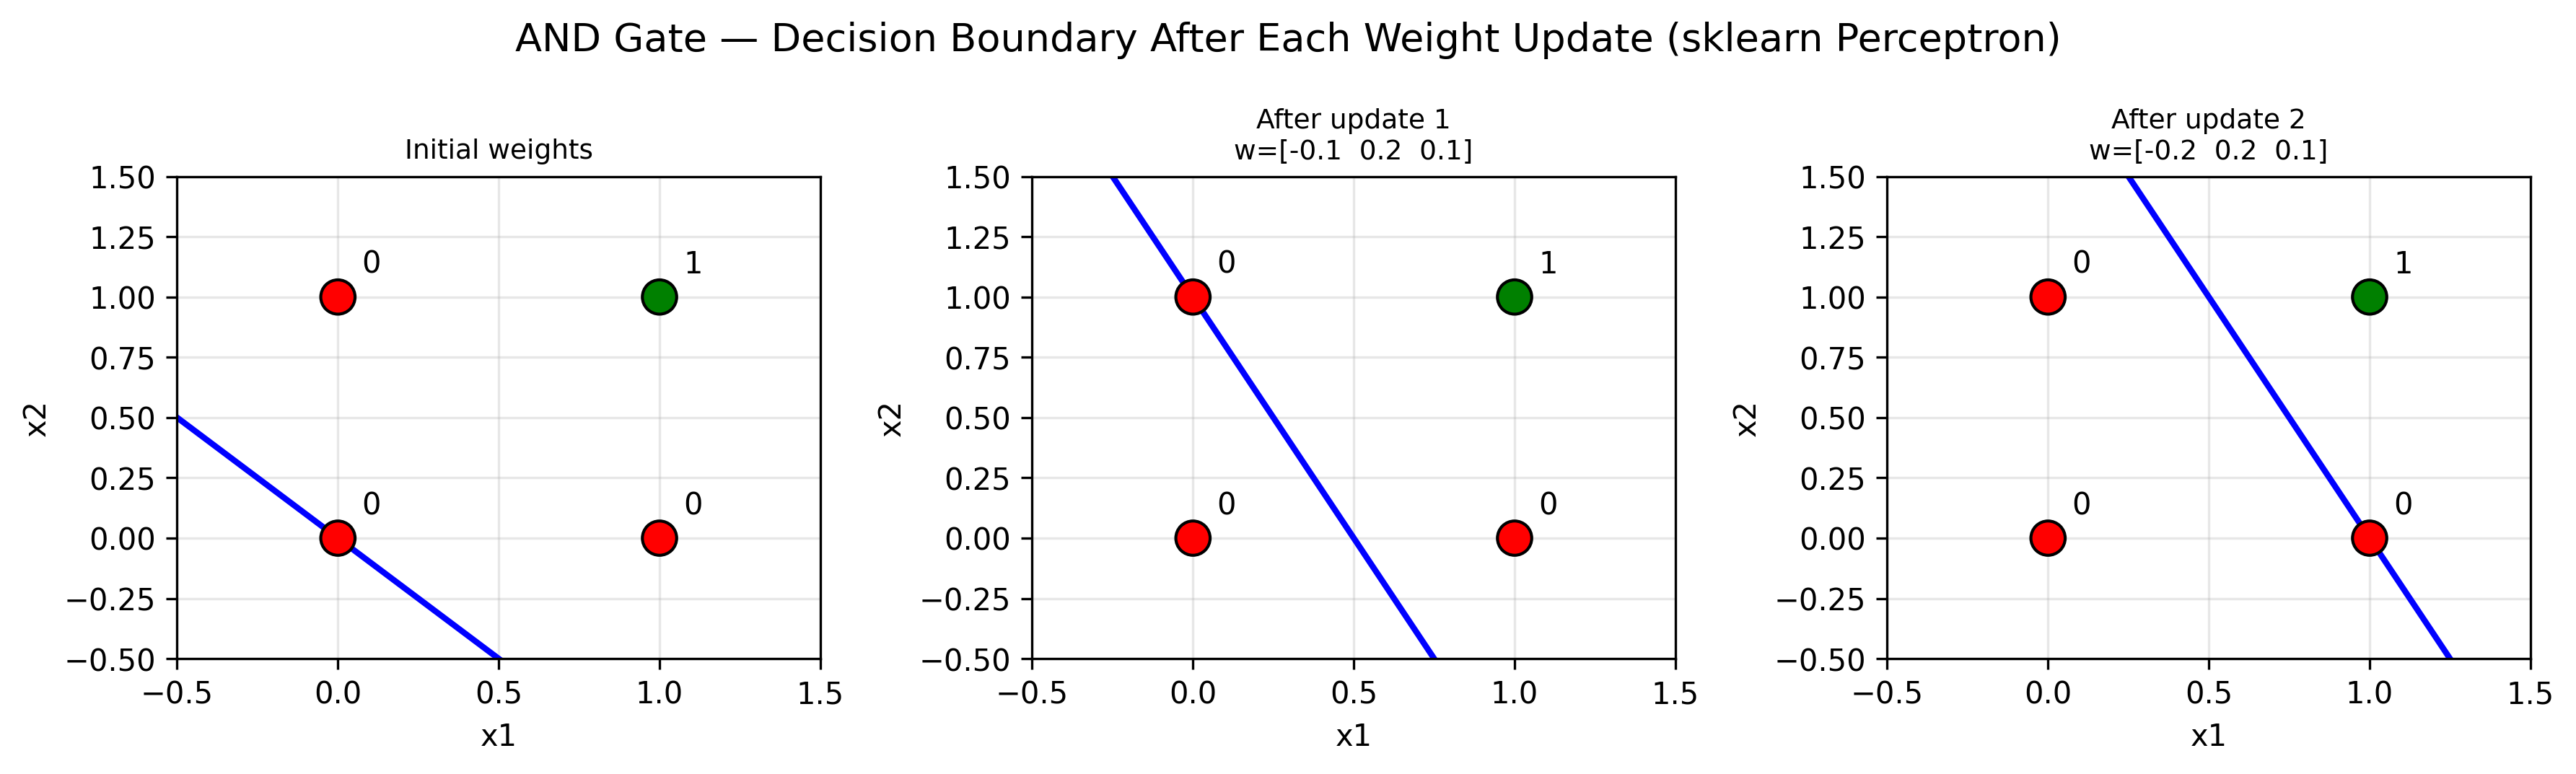

In [ ]:
sk_and, hist_and_sklearn = train_sklearn_with_history(X2, y_and)
plot_all_updates(X2, y_and, hist_and_sklearn, 'AND', 'sklearn Perceptron', dim=2)

Epoch  1 -> weights updated to [ 0.  -0.2]
Epoch  2 -> weights updated to [ 0.1 -0.2]

Final weights (bias, w1, ...): [ 0.1 -0.2]


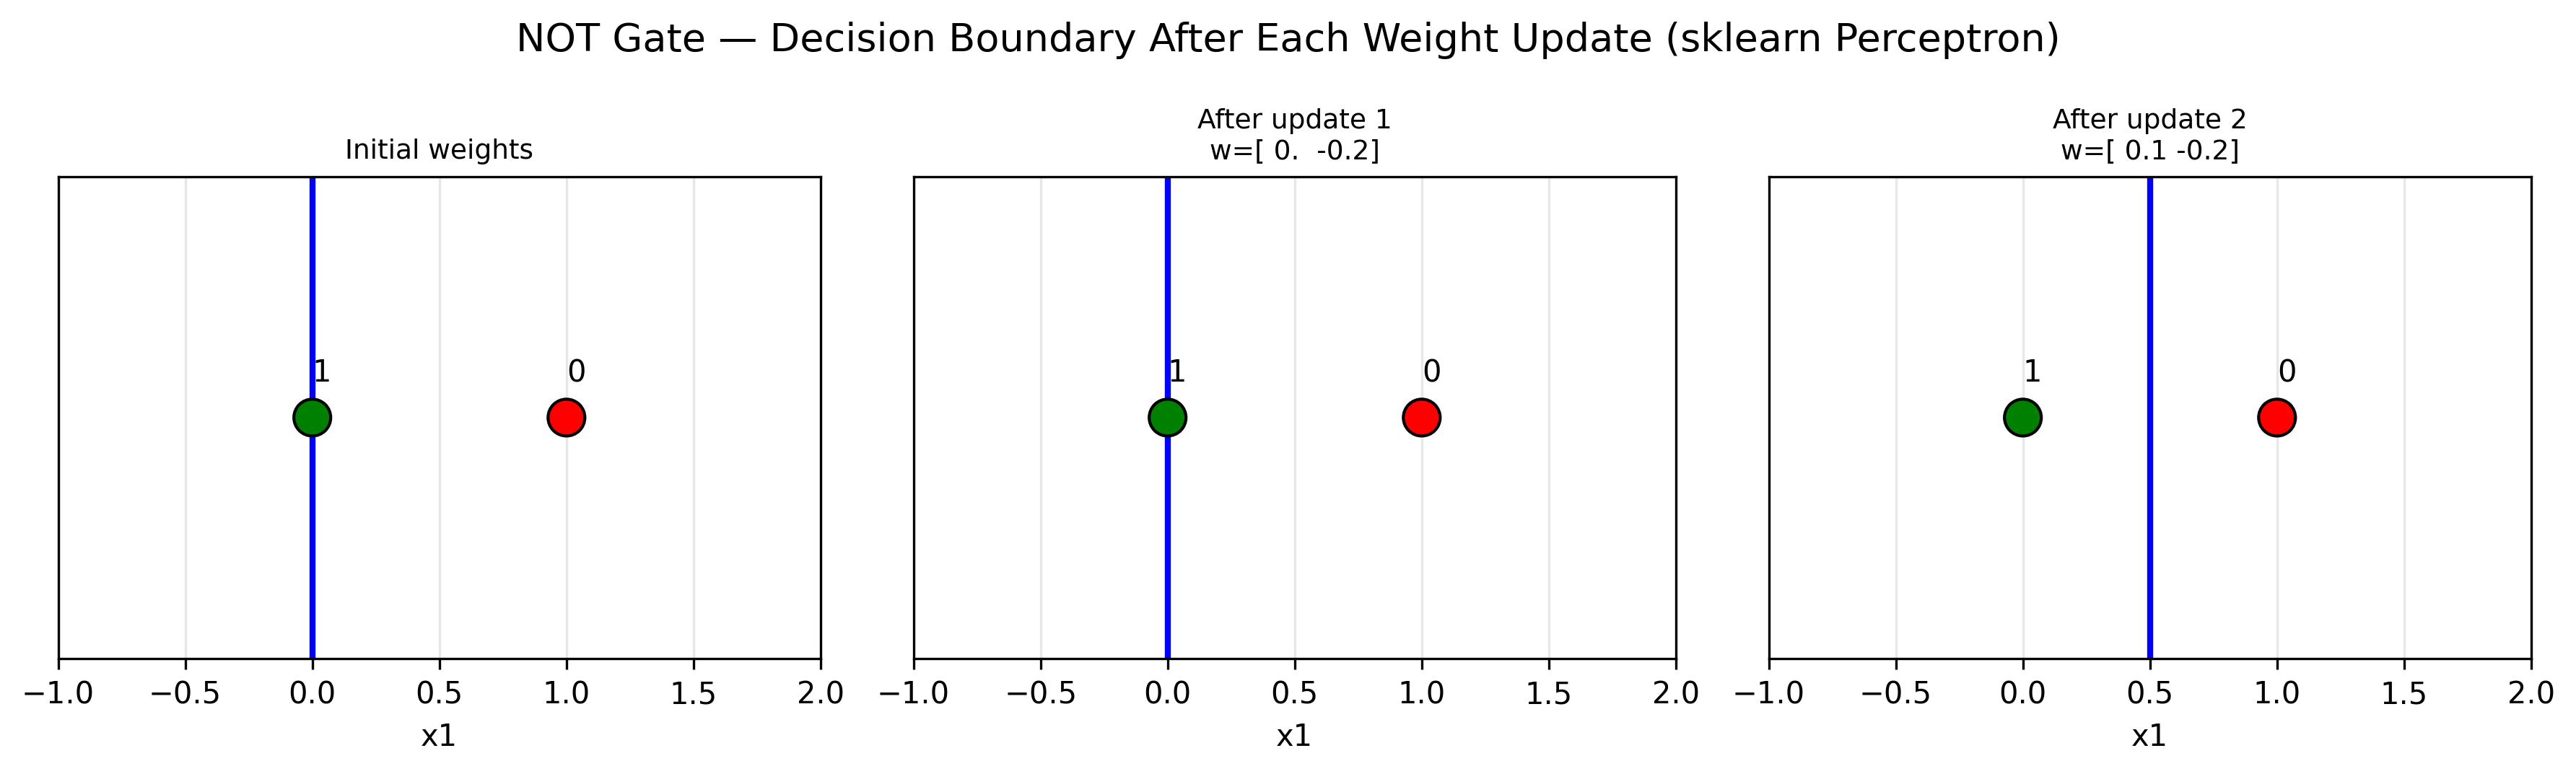

In [ ]:
sk_not, hist_not_sklearn = train_sklearn_with_history(X1, y_not)
plot_all_updates(X1, y_not, hist_not_sklearn, 'NOT', 'sklearn Perceptron', dim=1)

In [ ]:
def compare_final(gate_name, X, y, manual_w, sklearn_w, dim=2):
    print(f'--- {gate_name} gate ---')
    print('Manual  Perceptron final weights (bias, w...):', np.round(manual_w, 3))
    print('Sklearn Perceptron final weights (bias, w...):', np.round(sklearn_w, 3))

    fig, ax = plt.subplots(figsize=(5, 5))
    if dim == 2:
        plot_boundary_2d(X, y, manual_w, ax, '')
        w0, w1, w2 = sklearn_w
        x_vals = np.linspace(-0.5, 1.5, 100)
        if w2 != 0:
            ax.plot(x_vals, -(w0 + w1 * x_vals) / w2, 'm--', linewidth=2, label='sklearn boundary')
    else:
        plot_boundary_1d(X, y, manual_w, ax, '')
        w0, w1 = sklearn_w
        if w1 != 0:
            ax.axvline(-w0 / w1, color='m', linestyle='--', linewidth=2, label='sklearn boundary')

    ax.lines[0].set_label('manual boundary')
    ax.legend()
    ax.set_title(f'{gate_name}: Manual (blue solid) vs Sklearn (magenta dashed)')
    plt.show()
    print()

--- OR gate ---
Manual  Perceptron final weights (bias, w...): [-0.1  0.1  0.1]
Sklearn Perceptron final weights (bias, w...): [-0.1  0.2  0.2]


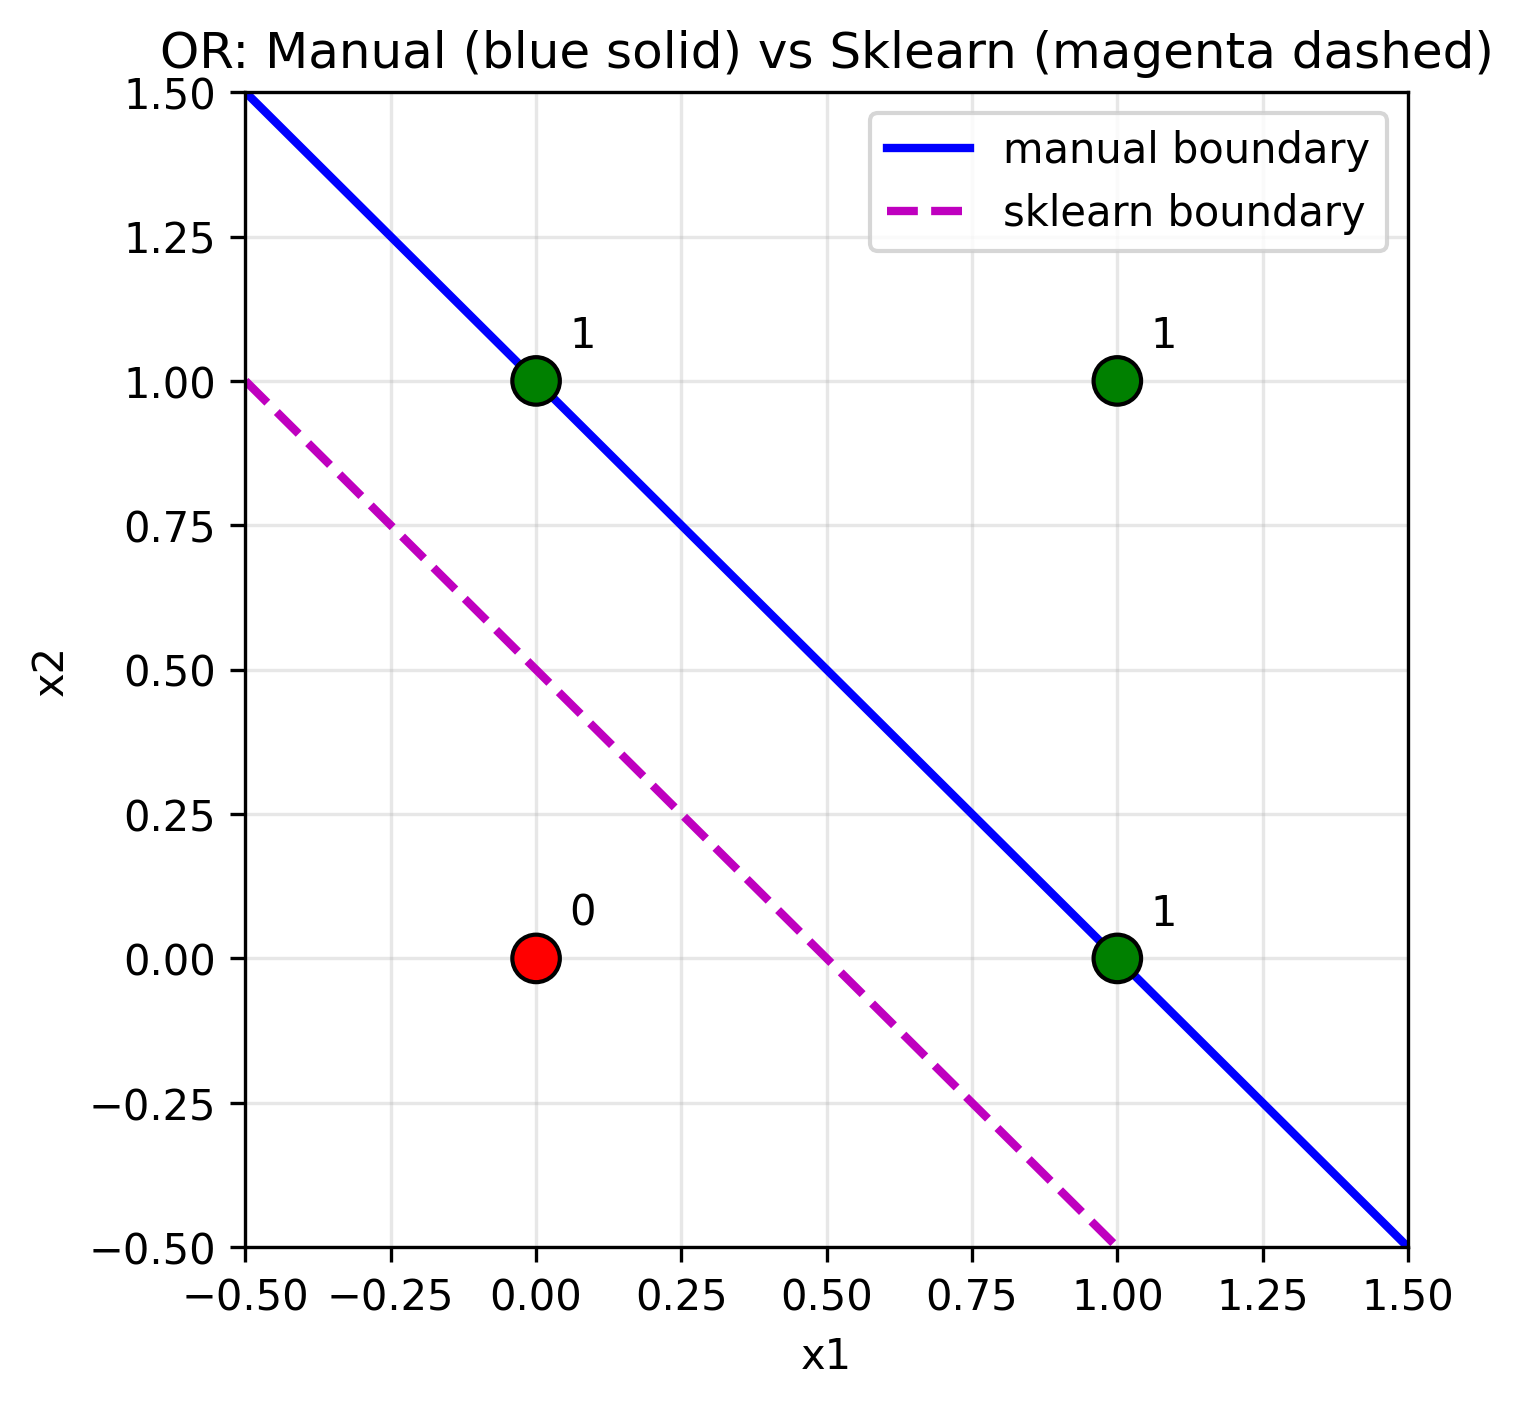


--- AND gate ---
Manual  Perceptron final weights (bias, w...): [-0.2  0.2  0.1]
Sklearn Perceptron final weights (bias, w...): [-0.2  0.2  0.1]


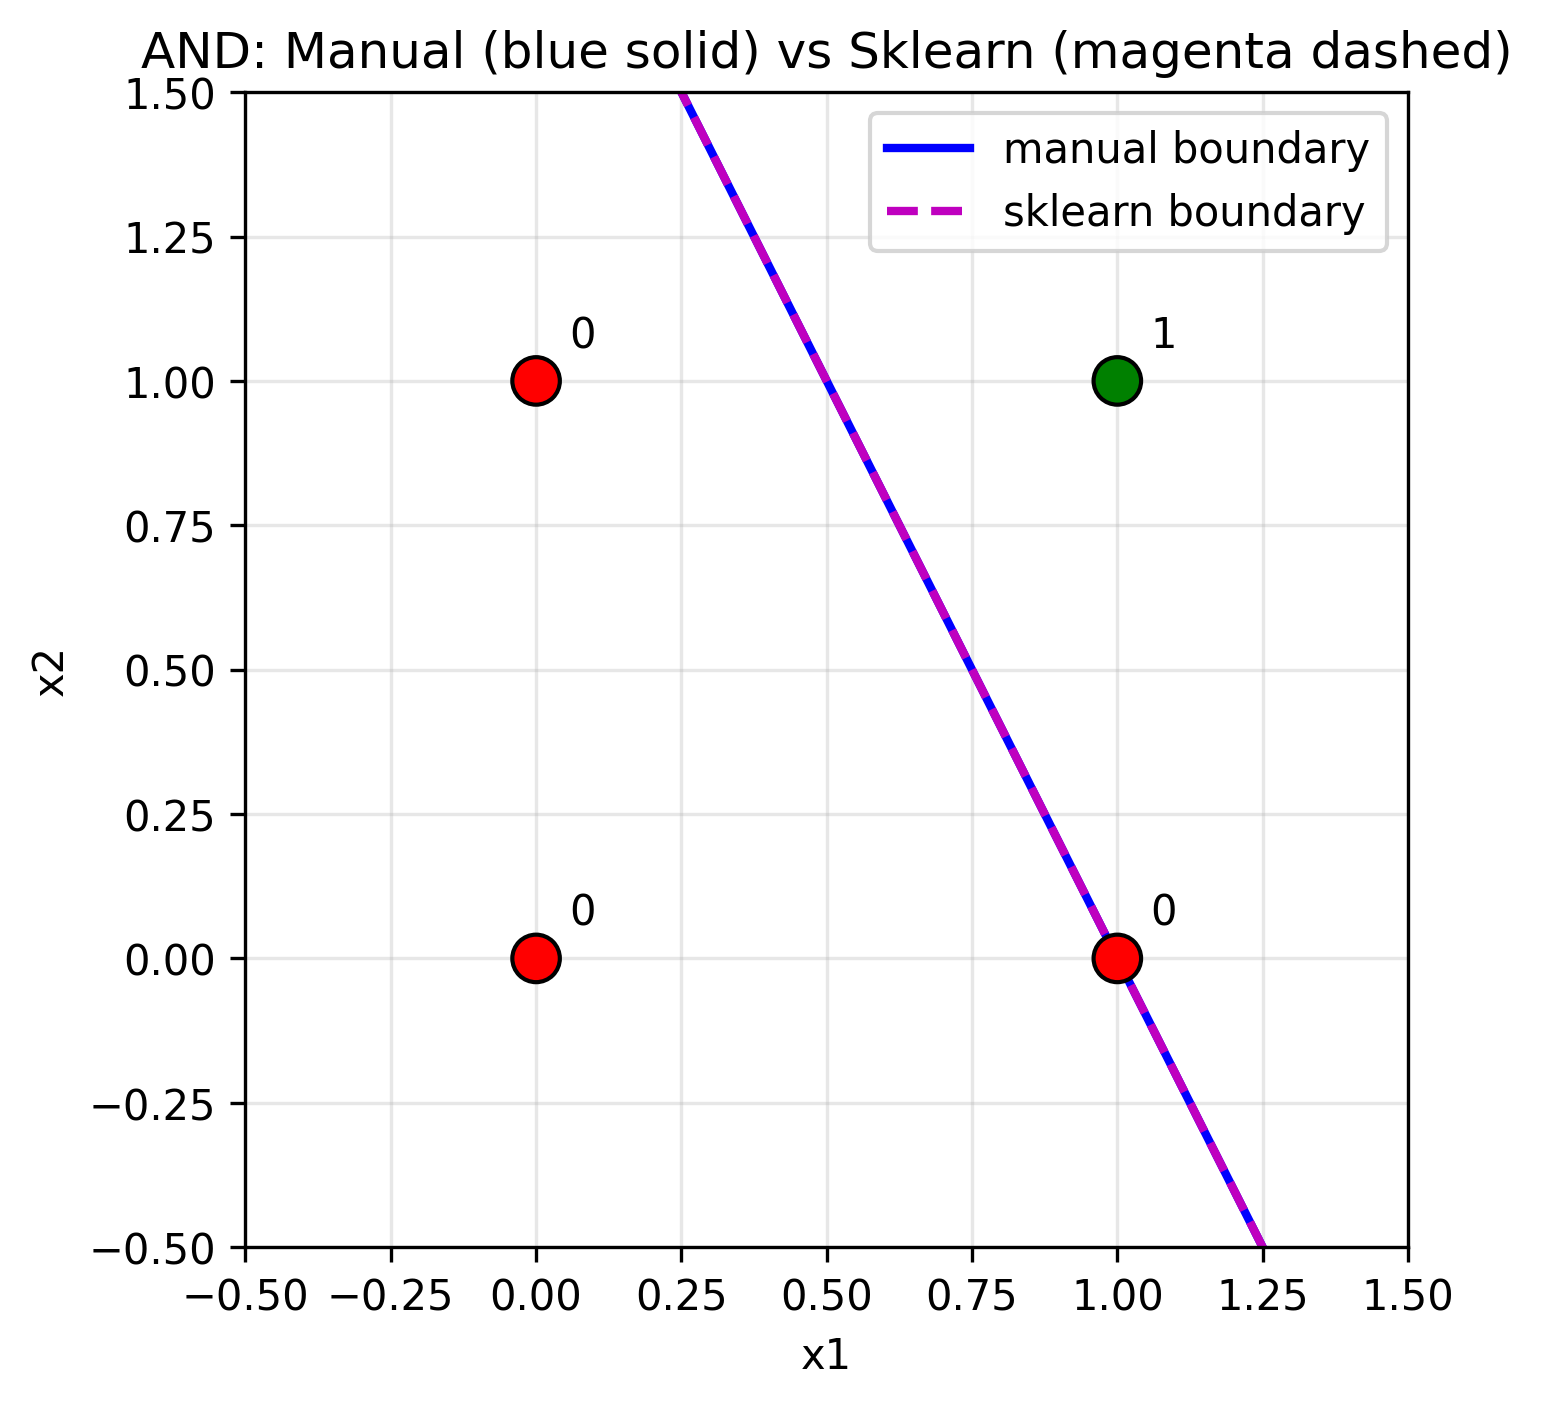


--- NOT gate ---
Manual  Perceptron final weights (bias, w...): [ 0.  -0.1]
Sklearn Perceptron final weights (bias, w...): [ 0.1 -0.2]


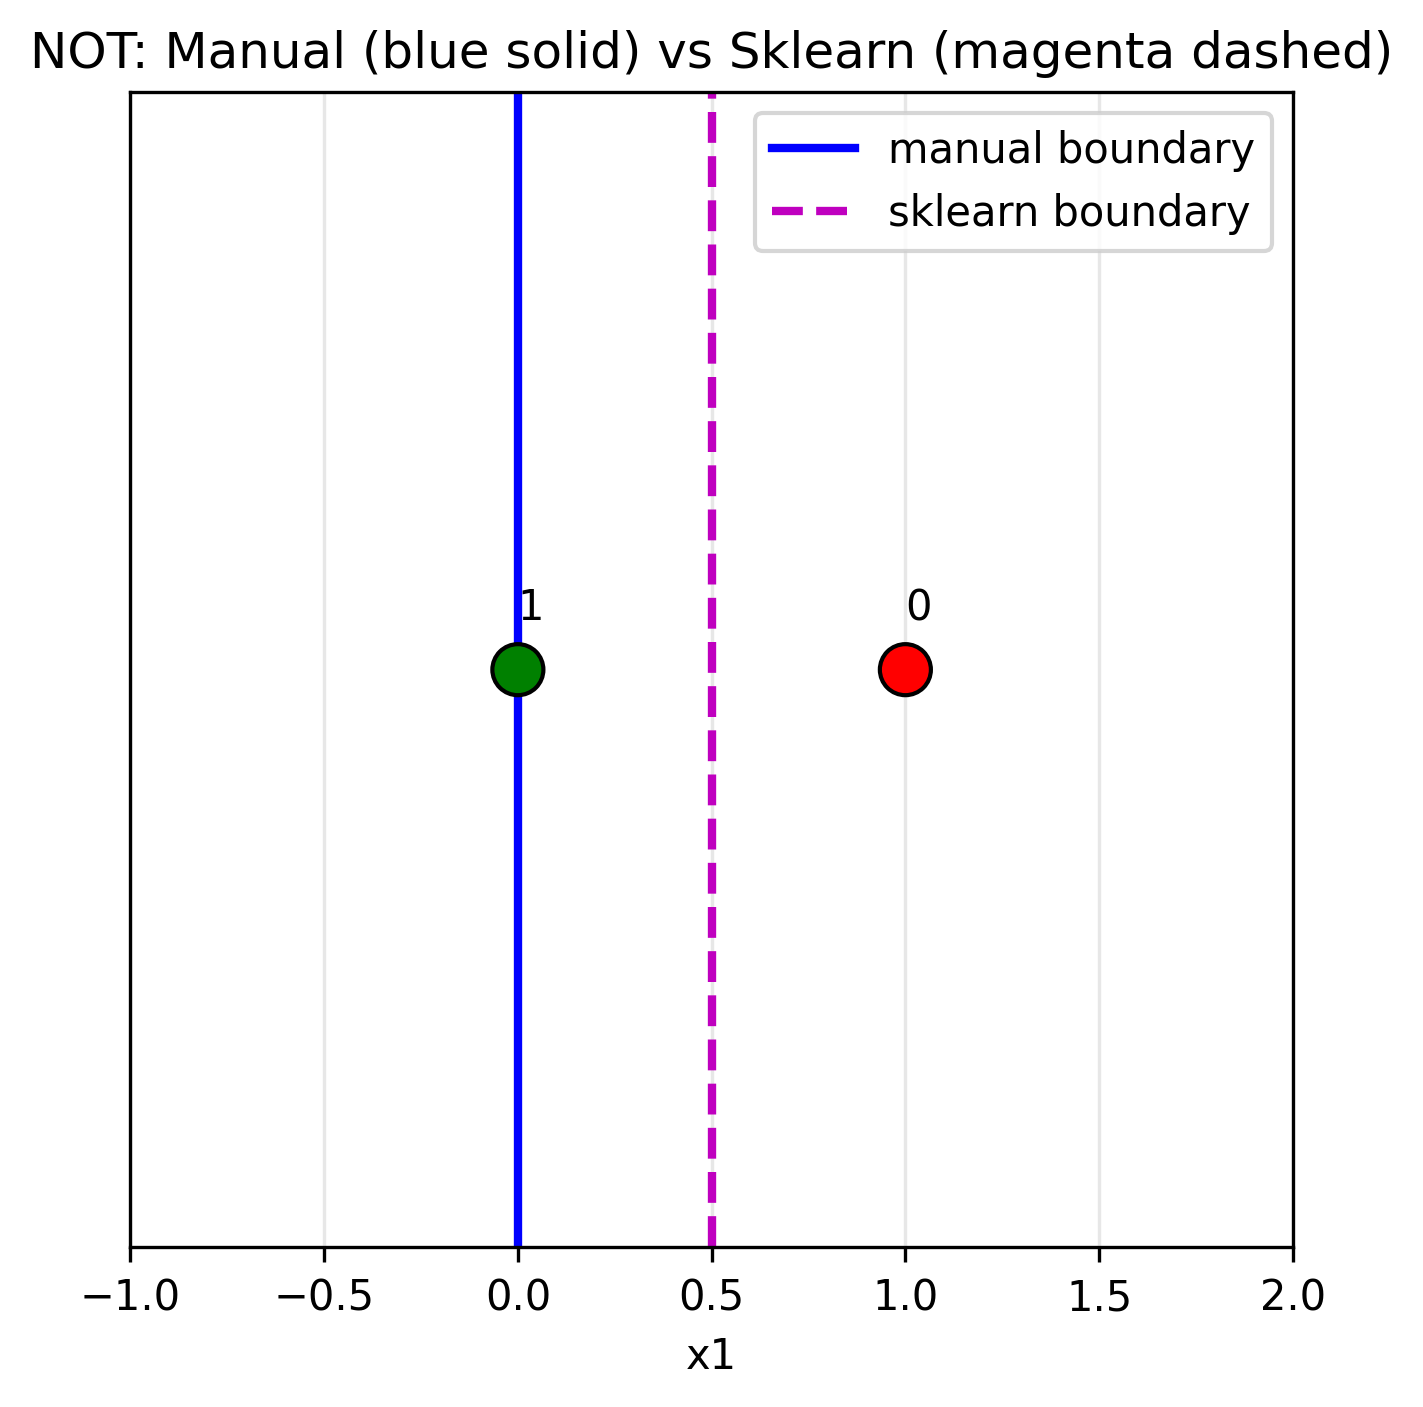

In [ ]:
compare_final('OR',  X2, y_or,  manual_or.weights,  hist_or_sklearn[-1],  dim=2)
compare_final('AND', X2, y_and, manual_and.weights, hist_and_sklearn[-1], dim=2)
compare_final('NOT', X1, y_not, manual_not.weights, hist_not_sklearn[-1], dim=1)